# Stress Level Analysis

## Motivation

Stress is something many of us, including me, are dealing with. It's rapidly becoming a major global public health concern. According to recent surveys (Statista), stress ranks just behind cancer and mental health issues as one of the most pressing challenges in several countries—especially in nations like South Korea and Turkey, where stress levels are notably high.

Younger populations, including students, are particularly vulnerable, although a considerable portion of older adults also report significant stress. This trend raises a crucial question: what factors are driving this surge in stress levels?

In this project, I aim to explore whether internal health-related and behavioral factors—such as sleep habits, fatigue, caffeine use, and physical activity—can be used to explain and even predict an individual’s stress level. Using a cleaned dataset on students’ lifestyle and sleep patterns, I will apply statistical analysis and machine learning techniques to identify potential stress indicators and build predictive models.


## Dataset Description

The dataset was originally obtained from a public source and contains various attributes such as:

- Sleep quality and duration
- Study habits
- Mental health and stress levels
- Academic outcomes (e.g., GPA)

I cleaned the dataset to remove invalid entries, convert categorical variables to numeric formats, and drop irrelevant features. Below is the cleaning code.


In [103]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("Student Insomnia and Educational Outcomes Dataset.csv")

# 2. Drop timestamp and strip question numbers
df.drop(columns=["Timestamp"], inplace=True)
df.columns = [col.split(" ", 1)[1].strip() for col in df.columns]

# 3. Define all mappings
year_map = {"First year": 1, "Second year": 2, "Third year": 3, "Graduate student": 4}
gender_map = {"Male": 0, "Female": 1}

fall_asleep_map = {
    "Never": 1, "Rarely (1-2 times a week)": 2, "Sometimes (3-4 times a week)": 3,
    "Often (5-6 times a week)": 4, "Every night": 5
}

sleep_hours_map = {"Less than 4 hours":1, "4-5 hours": 2, "6-7 hours": 3, "7-8 hours": 4, "More than 8 hours": 5}

wake_up_map = fall_asleep_map.copy()  # same scale as fall_asleep

sleep_quality_map = {
    "Very poor": 1, "Poor": 2, "Average": 3, "Good": 4, "Very good": 5
}

concentration_map = {
    "Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5
}

fatigue_map = concentration_map.copy()  # same as concentration

miss_class_map = {
    "Never": 1, "Rarely (1-2 times a month)": 2, "Sometimes (1-2 times a week)": 3,
    "Often (3-4 times a week)": 4, "Always": 5
}

impact_map = {"No impact": 1, "Minor impact": 2, "Moderate impact": 3, "Major impact": 4, "Severe impact": 5}

device_use_map = {
    "Never": 1, "Rarely (1-2 times a week)": 2, "Sometimes (3-4 times a week)": 3,
    "Often (5-6 times a week)": 4, "Every night": 5
}

caffeine_map = {
    "Never": 1, "Rarely (1-2 times a week)": 2, "Sometimes (3-4 times a week)": 3,
    "Often (5-6 times a week)": 4, "Every day": 5
}

exercise_map = caffeine_map.copy()  # same structure

stress_map = {
    "No stress": 1, "Low stress": 2, "High stress": 3, "Extremely high stress": 4
}

academic_perf_map = {
    "Poor": 1, "Below Average": 2, "Average": 3, "Good": 4, "Excellent": 5
}

# 4. Apply mappings
df["What is your year of study?"] = df["What is your year of study?"].map(year_map)
df["What is your gender?"] = df["What is your gender?"].map(gender_map)
df["How often do you have difficulty falling asleep at night?"] = df["How often do you have difficulty falling asleep at night?"].map(fall_asleep_map)
df["On average, how many hours of sleep do you get on a typical day?"] = df["On average, how many hours of sleep do you get on a typical day?"].map(sleep_hours_map)
df["How often do you wake up during the night and have trouble falling back asleep?"] = df["How often do you wake up during the night and have trouble falling back asleep?"].map(wake_up_map)
df["How would you rate the overall quality of your sleep?"] = df["How would you rate the overall quality of your sleep?"].map(sleep_quality_map)
df["How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?"] = df["How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?"].map(concentration_map)
df["How often do you feel fatigued during the day, affecting your ability to study or attend classes?"] = df["How often do you feel fatigued during the day, affecting your ability to study or attend classes?"].map(fatigue_map)
df["How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?"] = df["How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?"].map(miss_class_map)
df["How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?"] = df["How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?"].map(impact_map)
df["How often do you use electronic devices (e.g., phone, computer) before going to sleep?"] = df["How often do you use electronic devices (e.g., phone, computer) before going to sleep?"].map(device_use_map)
df["How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?"] = df["How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?"].map(caffeine_map)
df["How often do you engage in physical activity or exercise?"] = df["How often do you engage in physical activity or exercise?"].map(exercise_map)
df["How would you describe your stress levels related to academic workload?"] = df["How would you describe your stress levels related to academic workload?"].map(stress_map)
df["How would you rate your overall academic performance (GPA or grades) in the past semester?"] = df["How would you rate your overall academic performance (GPA or grades) in the past semester?"].map(academic_perf_map)

# 5. Rename to short column names
rename_map = {
    "What is your year of study?":              "year",
    "What is your gender?":                     "gender",
    "How often do you have difficulty falling asleep at night?": "fall_asleep",
    "On average, how many hours of sleep do you get on a typical day?": "sleep_hours",
    "How often do you wake up during the night and have trouble falling back asleep?": "wake_back",
    "How would you rate the overall quality of your sleep?":     "sleep_quality",
    "How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?": "concentration",
    "How often do you feel fatigued during the day, affecting your ability to study or attend classes?":  "fatigue",
    "How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?": "miss_class",
    "How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?": "impact_assignments",
    "How often do you use electronic devices (e.g., phone, computer) before going to sleep?": "device_use",
    "How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?": "caffeine_use",
    "How often do you engage in physical activity or exercise?": "exercise",
    "How would you describe your stress levels related to academic workload?": "stress_level",
    "How would you rate your overall academic performance (GPA or grades) in the past semester?": "academic_performance"
}

df.rename(columns=rename_map, inplace=True)

# 6. Save final cleaned dataset
df.to_csv("Clean.csv", index=False)
df.to_csv("Github Uploads/Clean.csv", index=False)

## Data Cleaning Summary

To prepare the dataset for analysis, we conducted the following cleaning steps:

1. **Removed unnecessary columns**: The `Timestamp` column was dropped as it provided no analytical value.

2. **Standardized column names**: I stripped question numbers and simplified column names for clarity and ease of use.

3. **Mapped categorical responses to numerical values**: Multiple survey responses (e.g., sleep frequency, stress levels, study habits) were converted into ordinal numeric scales using custom mappings. This allows for better compatibility with statistical analysis and machine learning models.

These preprocessing steps ensured that the dataset was tidy, numerical, and ready for exploratory analysis and modeling.


## Exploratory Data Analysis (EDA)

To begin the analysis, I first look at general summary statistics and visualize the distribution of key features in the dataset. This helps me understand the range, central tendency, and variation in behavioral factors that may relate to stress levels.


Dataset shape: (791, 15)


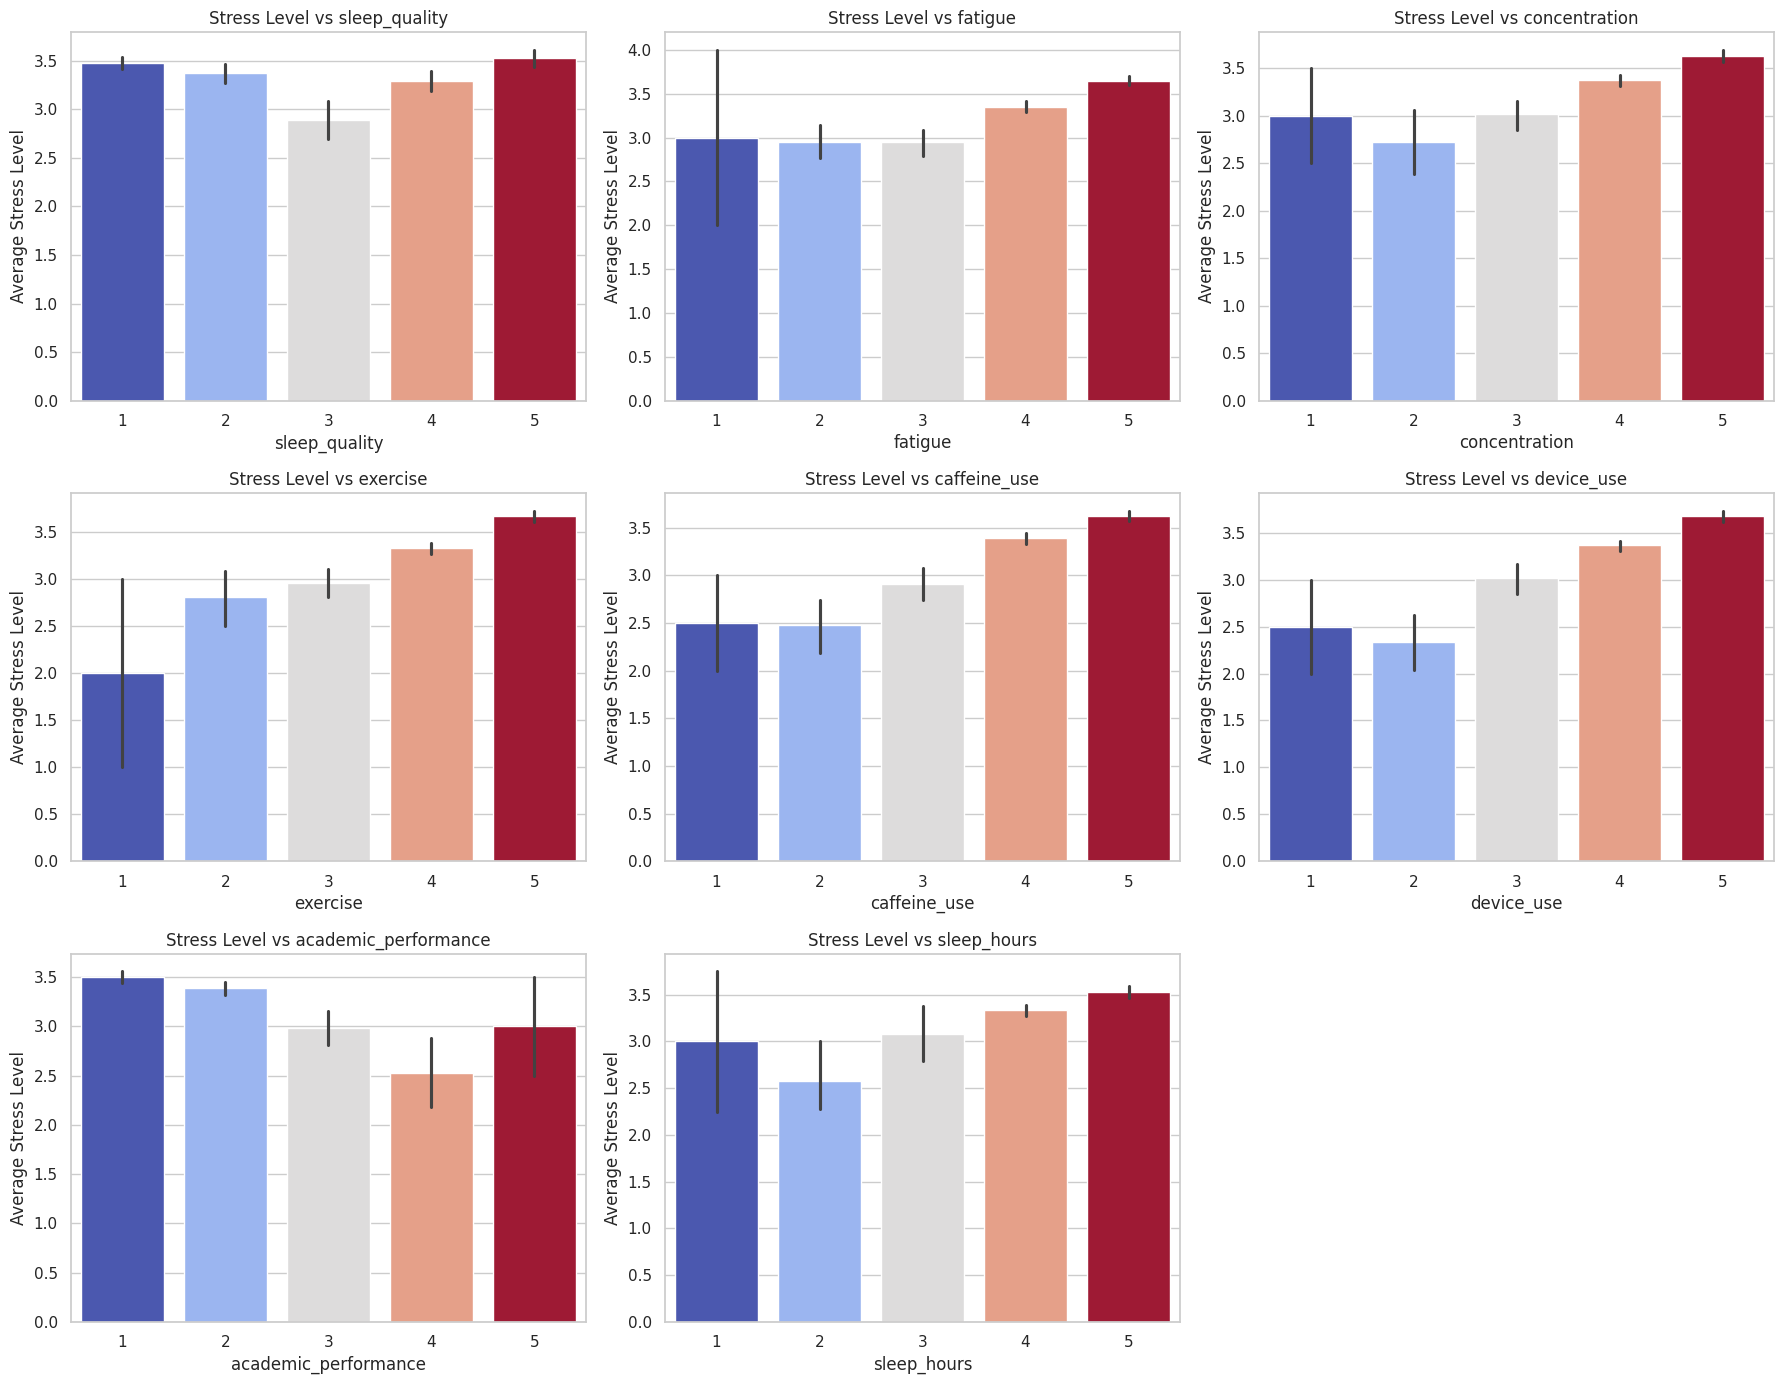

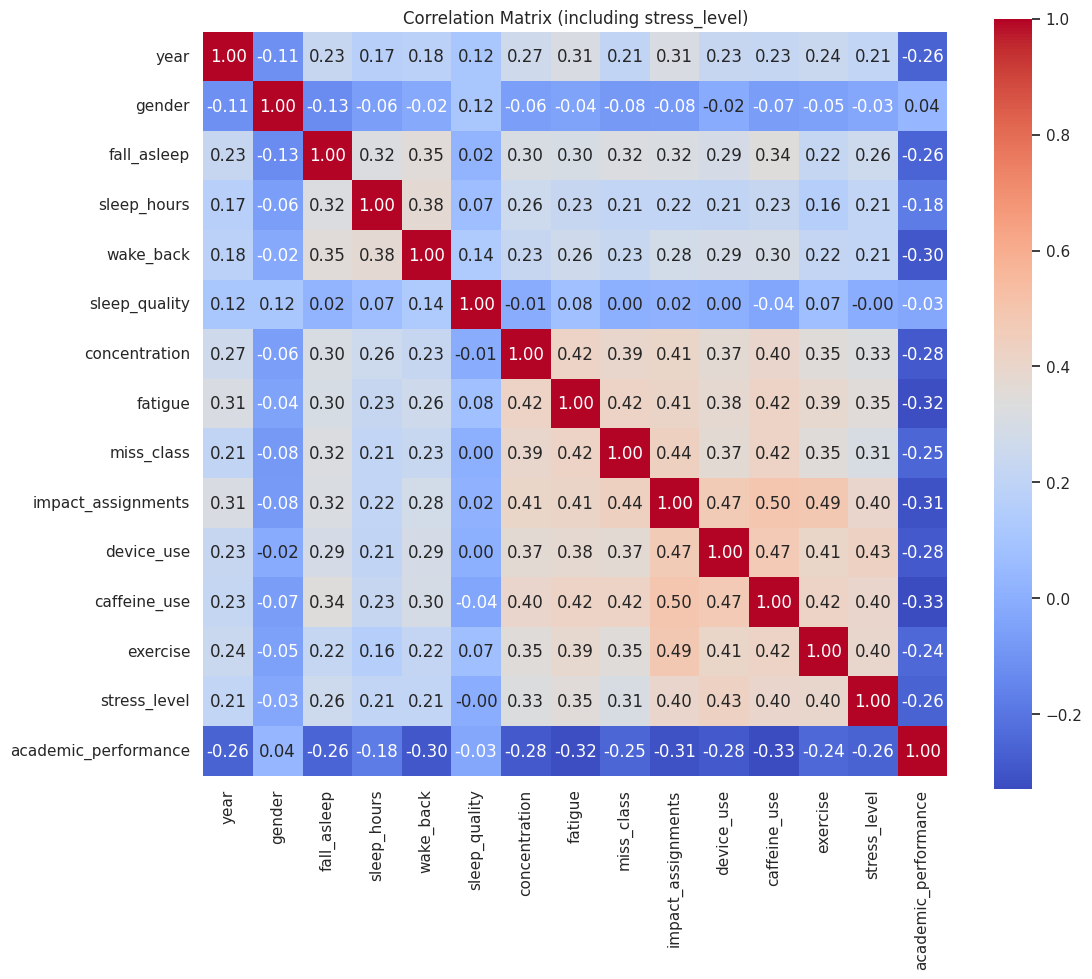

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextlib
import io

# Load dataset
df = pd.read_csv("Clean.csv")

# Only show dataset shape
print("Dataset shape:", df.shape)

# Suppress info and describe output
with contextlib.redirect_stdout(io.StringIO()):
    df.info()
    df.describe()

# Features to compare against stress level
features_to_plot = [
    'sleep_quality', 'fatigue', 'concentration', 'exercise',
    'caffeine_use', 'device_use', 'academic_performance', 'sleep_hours'
]

# Set plot style
sns.set(style="whitegrid")

# Create subplots: bar plots of average stress level per category (no warning version)
plt.figure(figsize=(18, 14))
for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1)
    sns.barplot(data=df, x=feature, y='stress_level', hue=feature, palette='coolwarm', legend=False)
    plt.title(f'Stress Level vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Average Stress Level')
plt.tight_layout()
plt.savefig("Github Uploads/stress_level_vs_features.png")
plt.show()

# Correlation heatmap including stress_level
plt.figure(figsize=(12, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (including stress_level)")
plt.savefig("Github Uploads/correlation_matrix.png")
plt.show()

### Sampling for Hypothesis Testing

While my full dataset includes 791 student responses, conducting hypothesis testing on the entire dataset often results in extremely small p-values. Even very small differences between groups can become statistically significant.

To address this, I draw a random sample of 100 students from the dataset. This smaller subset helps us:
- Reduce statistical overpowering
- Obtain p-values that are easier to interpret in real-world terms

If I don't do this, p-value will be extremely small which python rounds it to zero.

I use this sampled data to perform hypothesis testing and visualize group-level differences in stress levels.

In [105]:
import pandas as pd

# Load the cleaned dataset (if not already loaded)
df = pd.read_csv("Clean.csv")

# Take a random sample of 100 students (set seed for reproducibility)
sample_df = df.sample(n=100, random_state=42)

# Save the sampled dataset
sample_df.to_csv("Sampled_100.csv", index=False)
sample_df.to_csv("Github Uploads/Sampled_100.csv", index=False)

# Confirm
print("Sampled dataset shape:", sample_df.shape)
print("Sample saved as 'Sampled_100.csv'")

Sampled dataset shape: (100, 15)
Sample saved as 'Sampled_100.csv'


## Hypothesis Testing

In this section, I test whether specific behavioral and lifestyle factors significantly influence stress levels among students. I selected two hypotheses based on plausible real-world relationships:

---

### 🔹 Hypothesis 1: Sleep Hours and Stress Level

**Question:** Does the average amount of sleep a student gets significantly affect their stress level?

**Null Hypothesis (H₀):** The mean stress level is the same across all sleep hour groups.

**Alternative Hypothesis (H₁):** Sleep hours could affect the stress level across groups.

I perform a **ANOVA** test to compare mean stress levels between groups categorized by average sleep duration.

---

### 🔹 Hypothesis 2: Caffeine Use and Stress Level

**Question:** Is there a significant relationship between how frequently students consume caffeine and their stress level?

**Null Hypothesis (H₀):** There is no correlation between caffeine use and stress level.

**Alternative Hypothesis (H₁):** There is a correlation between caffeine use and stress level.

I use the **Spearman rank correlation** to test for a non-linear but monotonic relationship between these ordinal features.


In [106]:
from scipy.stats import f_oneway, spearmanr

# --- Hypothesis 1: Sleep Hours vs Stress Level (One-Way ANOVA) ---
# Group stress_level by unique values of sleep_hours
groups_sleep = [sample_df[sample_df['sleep_hours'] == val]['stress_level'] for val in sorted(sample_df['sleep_hours'].dropna().unique())]

# Perform ANOVA
anova_stat, anova_p = f_oneway(*groups_sleep)

print("Hypothesis 1: Sleep Hours and Stress Level")
print(f"ANOVA p-value = {anova_p:.6f}")
if anova_p < 0.05:
    print("→ Result: Reject the null hypothesis — sleep hours do significantly affect stress level.\n")
else:
    print("→ Result: Fail to reject the null hypothesis — no significant difference between sleep groups.\n")

# --- Hypothesis 2: Caffeine Use vs Stress Level (Spearman correlation) ---
spearman_corr, spearman_p = spearmanr(sample_df['caffeine_use'], sample_df['stress_level'])

print("Hypothesis 2: Caffeine Use and Stress Level")
print(f"Spearman correlation = {spearman_corr:.3f}")
print(f"Spearman p-value     = {spearman_p:.6f}")
if spearman_p < 0.05:
    print("→ Result: Reject the null hypothesis — caffeine use is correlated with stress level.")
else:
    print("→ Result: Fail to reject the null hypothesis — no significant correlation.")

Hypothesis 1: Sleep Hours and Stress Level
ANOVA p-value = 0.002543
→ Result: Reject the null hypothesis — sleep hours do significantly affect stress level.

Hypothesis 2: Caffeine Use and Stress Level
Spearman correlation = 0.496
Spearman p-value     = 0.000000
→ Result: Reject the null hypothesis — caffeine use is correlated with stress level.


### Hypothesis Testing Results

#### 🔹 Hypothesis 1: Sleep Hours and Stress Level
I performed a One-Way ANOVA test on the sampled data to assess whether average sleep duration has a statistically significant effect on students' stress levels.

- **Result:** The ANOVA test returned a p-value of *0.002543*.
- **Conclusion:** Since the p-value was below 0.05, I reject the null hypothesis. This suggests that the amount of sleep a student gets **does have a significant effect** on their stress level.

#### 🔹 Hypothesis 2: Caffeine Use and Stress Level
I used the Spearman rank correlation test to examine whether there's a monotonic relationship between how frequently students consume caffeine and their reported stress level.

- **Result:** The test yielded a Spearman correlation of *0.496* and a p-value of *0.000000*.
- **Conclusion:** The p-value is extremely small and below 0.05, so we reject the null hypothesis. This indicates a statistically significant correlation between **caffeine consumption and stress level** — as caffeine use increases, stress level tends to rise as well.

These findings highlight the role of sleep and caffeine intake in student stress, supporting the idea that behavioral factors meaningfully contribute to mental well-being.


### Visualizing Hypothesis Test Results

To better understand the patterns found in my hypothesis tests, I use bar plots to visualize the relationship between:

- Average sleep hours and stress level
- Caffeine use frequency and stress level

These visualizations help illustrate how these variables influence student stress.


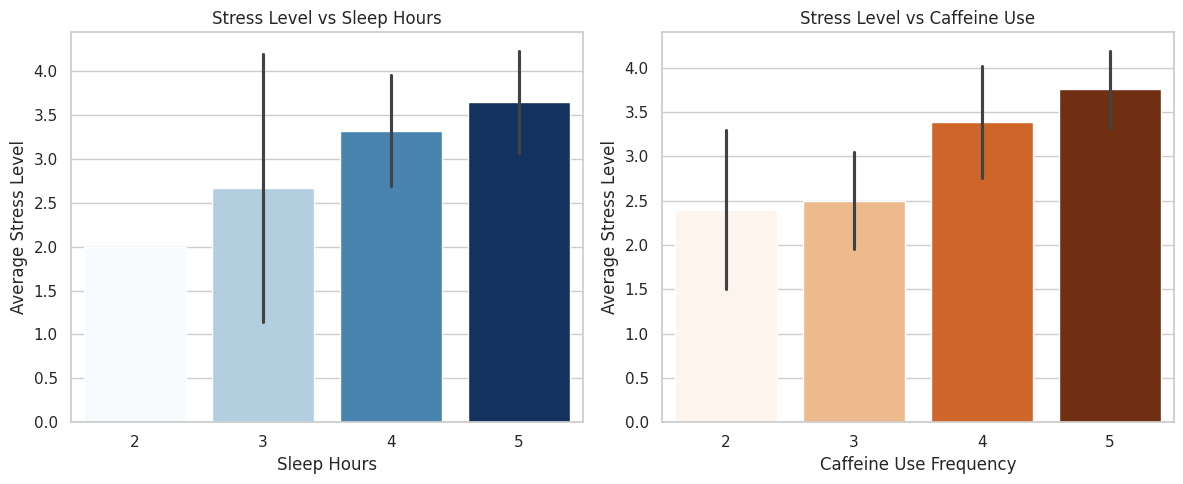

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Plot: Stress Level by Sleep Hours and Caffeine Use (No warnings)
plt.figure(figsize=(12, 5))

# Sleep Hours
plt.subplot(1, 2, 1)
sns.barplot(
    data=sample_df,
    x="sleep_hours",
    y="stress_level",
    hue="sleep_hours",
    palette="Blues",
    errorbar="sd",
    legend=False
)
plt.title("Stress Level vs Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Average Stress Level")

# Caffeine Use
plt.subplot(1, 2, 2)
sns.barplot(
    data=sample_df,
    x="caffeine_use",
    y="stress_level",
    hue="caffeine_use",
    palette="Oranges",
    errorbar="sd",
    legend=False
)
plt.title("Stress Level vs Caffeine Use")
plt.xlabel("Caffeine Use Frequency")
plt.ylabel("Average Stress Level")

plt.tight_layout()
plt.savefig("Github Uploads/stress_vs_sleep_caffeine.png")
plt.show()

## Machine Learning Modeling

In this phase, I aim to build predictive models to estimate a student's stress level based on behavioral and physiological features. My goal is to assess whether these features can reliably predict stress categories using supervised classification techniques.

I will:
- Split the data into training and testing sets
- Train multiple models (e.g., Random Forest, KNN)
- Evaluate model accuracy and compare performance
- Visualize ROC-AUC to measure classification quality


### Focused ROC Curve: Stressed vs. Not Stressed

To better identify students under high stress, I transformed the original 4-class stress levels into a binary classification:

- **Not Stressed (0):** No stress or low stress
- **Stressed (1):** High stress or extremely high stress

I then plot the ROC curve to evaluate each model’s ability to distinguish stressed students from those not under significant stress. This focused evaluation helps assess real-world usefulness in detecting at-risk individuals.


In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the full cleaned dataset
df = pd.read_csv("Clean.csv")

# Binary label: stress_level → 0 = Not Stressed (1–2), 1 = Stressed (3–4)
df["binary_stress"] = df["stress_level"].apply(lambda x: 0 if x in [1, 2] else 1)

# Drop old target from features
X = df.drop(columns=["stress_level", "binary_stress"])
y = df["binary_stress"]

# Stratified 70% train / 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Save splits to CSV
X_train.to_csv("X_train_sample.csv", index=False)
X_test.to_csv("X_test_sample.csv", index=False)
y_train.to_csv("y_train_binary.csv", index=False)
y_test.to_csv("y_test_binary.csv", index=False)
X_train.to_csv("Github Uploads/X_train_sample.csv", index=False)
X_test.to_csv("Github Uploads/X_test_sample.csv", index=False)
y_train.to_csv("Github Uploads/y_train_binary.csv", index=False)
y_test.to_csv("Github Uploads/y_test_binary.csv", index=False)

# Display class distributions
print("✅ Full dataset 70/30 stratified split completed.")
print("Train class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

✅ Full dataset 70/30 stratified split completed.
Train class distribution:
 binary_stress
1    517
0     36
Name: count, dtype: int64

Test class distribution:
 binary_stress
1    222
0     16
Name: count, dtype: int64


### Multi-Model Comparison: Binary Stress Classification

With the stress levels now grouped into a binary format (Stressed vs Not Stressed), I train and evaluate multiple machine learning models to identify students under significant stress.

Each model will be evaluated using:
- **Accuracy**: Overall prediction correctness
- **ROC-AUC Score**: Ability to distinguish stressed students from non-stressed ones
- **ROC Curve**: Visual performance comparison

I begin with a new model — Random Forest — and will gradually compare it against others including Logistic Regression, KNN, SVM, and XGBoost.



Random Forest (Binary Classification)
-------------------------------------
✔ Accuracy: 0.93
✔ ROC-AUC:  0.85



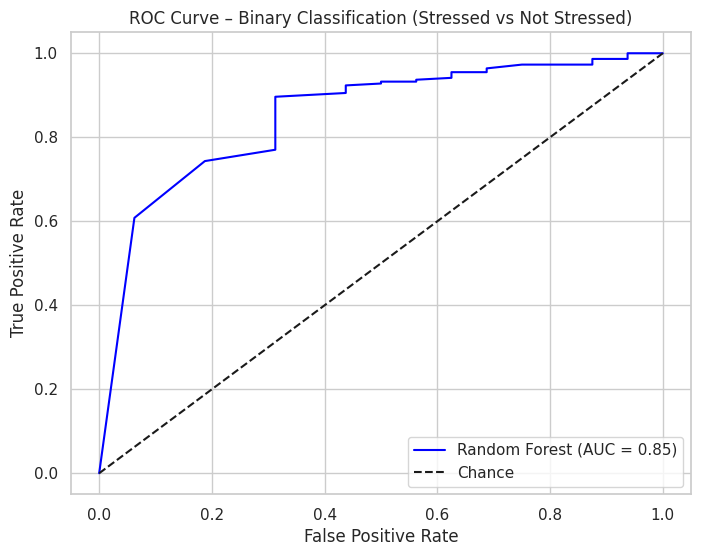

In [109]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load data
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # P(stressed = 1)

# Evaluate
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Summary
summary_text = f"""
Random Forest (Binary Classification)
-------------------------------------
✔ Accuracy: {acc:.2f}
✔ ROC-AUC:  {roc_auc:.2f}
"""
print(summary_text)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})", color="blue")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary Classification (Stressed vs Not Stressed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("Github Uploads/random_forest_roc_curve.png")
plt.show()

### K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a simple, instance-based learning algorithm that classifies a sample based on the majority class of its closest training samples.

I evaluate it using accuracy and ROC-AUC to see how well it distinguishes stressed from non-stressed students.



K-Nearest Neighbors (Using Full Dataset)
----------------------------------------
✔ Accuracy: 0.92
✔ ROC-AUC:  0.78



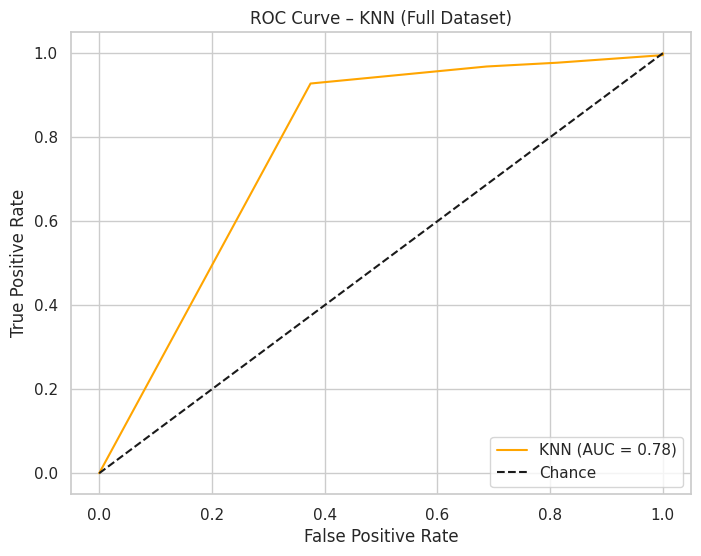

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Load the full dataset split
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1 (stressed)

# Evaluate
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Print summary
summary_text = f"""
K-Nearest Neighbors (Using Full Dataset)
----------------------------------------
✔ Accuracy: {acc:.2f}
✔ ROC-AUC:  {roc_auc:.2f}
"""
print(summary_text)

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.2f})", color="orange")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN (Full Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("Github Uploads/knn_roc_curve.png")
plt.show()

### Support Vector Machine (SVM)

Support Vector Machines are powerful classifiers that aim to find the optimal decision boundary (hyperplane) that separates classes. In binary stress classification, SVM attempts to separate stressed and non-stressed students using maximum margin.



Support Vector Machine (Binary Classification)
----------------------------------------------
✔ Accuracy: 0.91
✔ ROC-AUC:  0.87



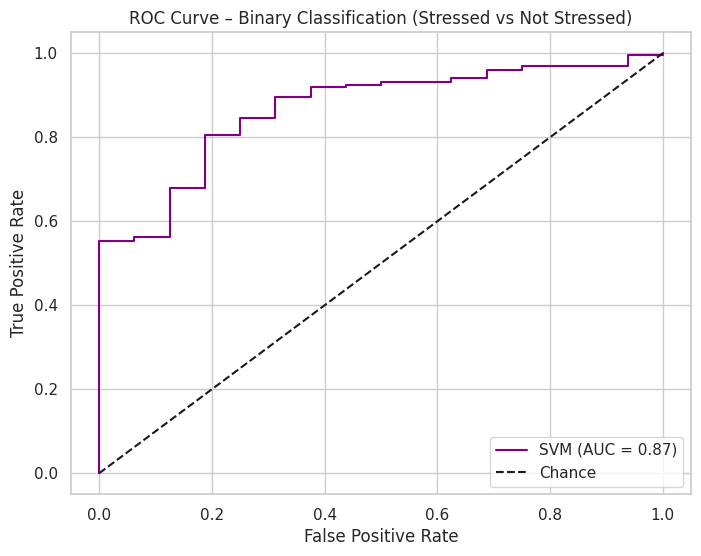

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Load data
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# Scale features (SVM is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with probability=True for ROC
svm = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train_scaled, y_train)

# Predict
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]  # P(stressed = 1)

# Evaluate
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Summary
summary_text = f"""
Support Vector Machine (Binary Classification)
----------------------------------------------
✔ Accuracy: {acc:.2f}
✔ ROC-AUC:  {roc_auc:.2f}
"""
print(summary_text)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})", color="purple")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary Classification (Stressed vs Not Stressed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("Github Uploads/svm_roc_curve.png")
plt.show()

### XGBoost (Extreme Gradient Boosting)

XGBoost is a powerful tree-based ensemble learning algorithm known for its speed and performance. It uses gradient boosting to build decision trees sequentially, optimizing for prediction accuracy.

In this step, I train XGBoost to predict student stress (binary: stressed vs not stressed), and evaluate its performance using accuracy and ROC-AUC.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:49:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost (Binary Classification)
-------------------------------
✔ Accuracy: 0.91
✔ ROC-AUC:  0.85



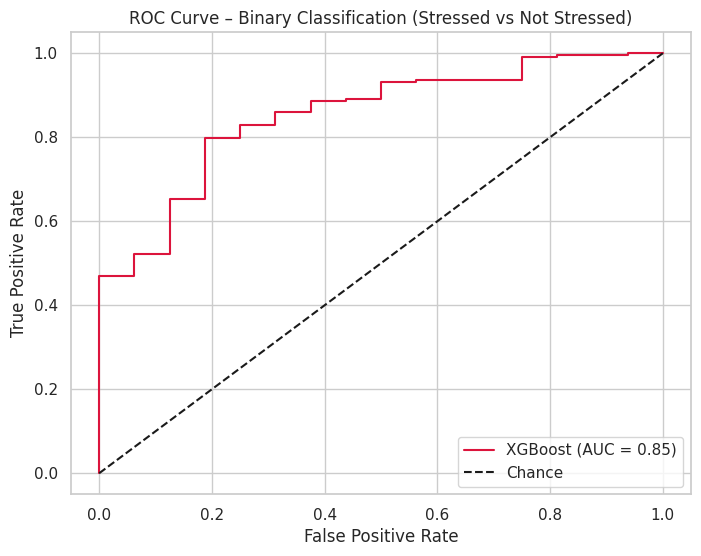

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Load data
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# (Optional) scale features if you want consistent comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]  # P(stressed = 1)

# Evaluate
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Summary
summary_text = f"""
XGBoost (Binary Classification)
-------------------------------
✔ Accuracy: {acc:.2f}
✔ ROC-AUC:  {roc_auc:.2f}
"""
print(summary_text)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})", color="crimson")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary Classification (Stressed vs Not Stressed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("Github Uploads/xgboost_roc_curve.png")
plt.show()

### Logistic Regression (Binary Classification)

Logistic Regression is a linear model that predicts probabilities of class membership. It serves as a strong and interpretable baseline, especially for small or structured datasets. I train it with class balancing enabled and evaluate it using accuracy and ROC-AUC.



Logistic Regression (Binary Classification)
-------------------------------------------
✔ Accuracy: 0.86
✔ ROC-AUC:  0.92



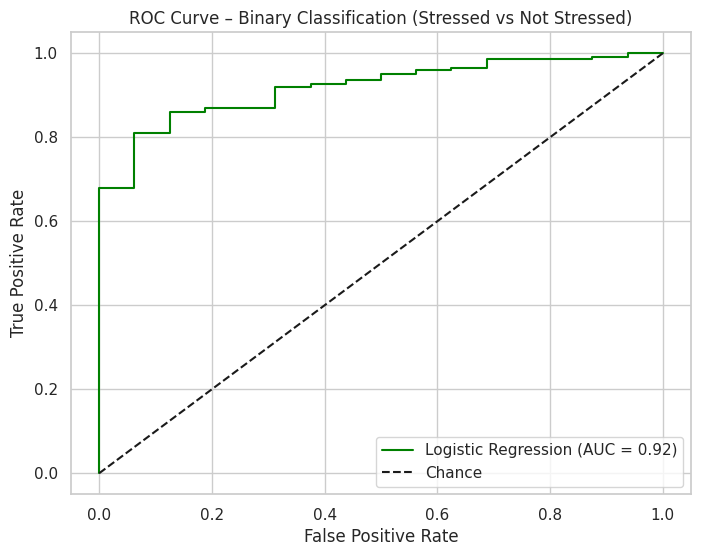

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Load data
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression with class balancing
logreg = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

# Predict
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # P(stressed = 1)

# Evaluate
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Summary
summary_text = f"""
Logistic Regression (Binary Classification)
-------------------------------------------
✔ Accuracy: {acc:.2f}
✔ ROC-AUC:  {roc_auc:.2f}
"""
print(summary_text)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary Classification (Stressed vs Not Stressed)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("Github Uploads/logistic_regression_roc_curve.png")
plt.show()

### Final Model Comparison

After training all models on the same dataset using binary stress labels (Stressed vs Not Stressed), I now compare their performance using ROC curves.

The ROC-AUC score provides a robust measure of each model’s ability to distinguish between stressed and non-stressed students. Below, we visualize and compare the ROC curves of Logistic Regression, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and XGBoost.

This comparison helps identify the most effective model for detecting high-stress students based on behavioral and physiological indicators.


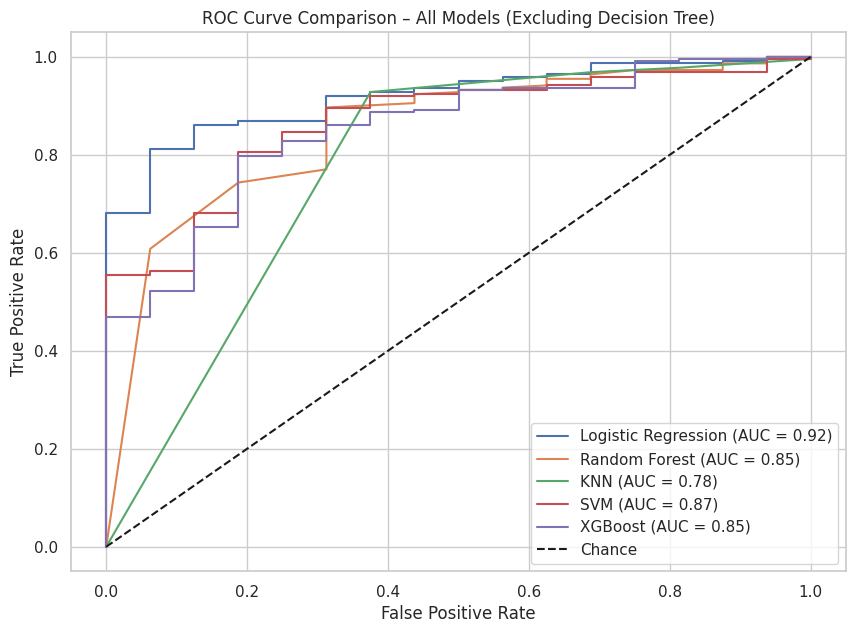

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import os

# Load data
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# Scale features for scale-sensitive models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models to compare (excluding Decision Tree)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

# Determine which models need scaled inputs
use_scaled = ["Logistic Regression", "KNN", "SVM", "XGBoost"]

# Plot
plt.figure(figsize=(10, 7))
for name, model in models.items():
    X_tr = X_train_scaled if name in use_scaled else X_train
    X_te = X_test_scaled if name in use_scaled else X_test

    model.fit(X_tr, y_train)
    y_proba = model.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Finalize plot
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – All Models (Excluding Decision Tree)")
plt.legend(loc="lower right")
plt.grid(True)

os.makedirs("Github Uploads", exist_ok=True)
plt.savefig("Github Uploads/roc_comparison_all_models.png")
plt.show()

### Confusion Matrix Comparison

To better understand how each model makes predictions, I visualize their confusion matrices. Each matrix shows the number of correct and incorrect predictions made by the model, broken down by the two classes:

- **True Positives (bottom-right)**: Correctly predicted "Stressed" students  
- **True Negatives (top-left)**: Correctly predicted "Not Stressed" students  
- **False Positives (top-right)**: Predicted "Stressed" when actually not  
- **False Negatives (bottom-left)**: Missed actual "Stressed" cases

This breakdown complements the ROC-AUC analysis by showing where each model struggles — particularly in handling class imbalance or distinguishing borderline cases.


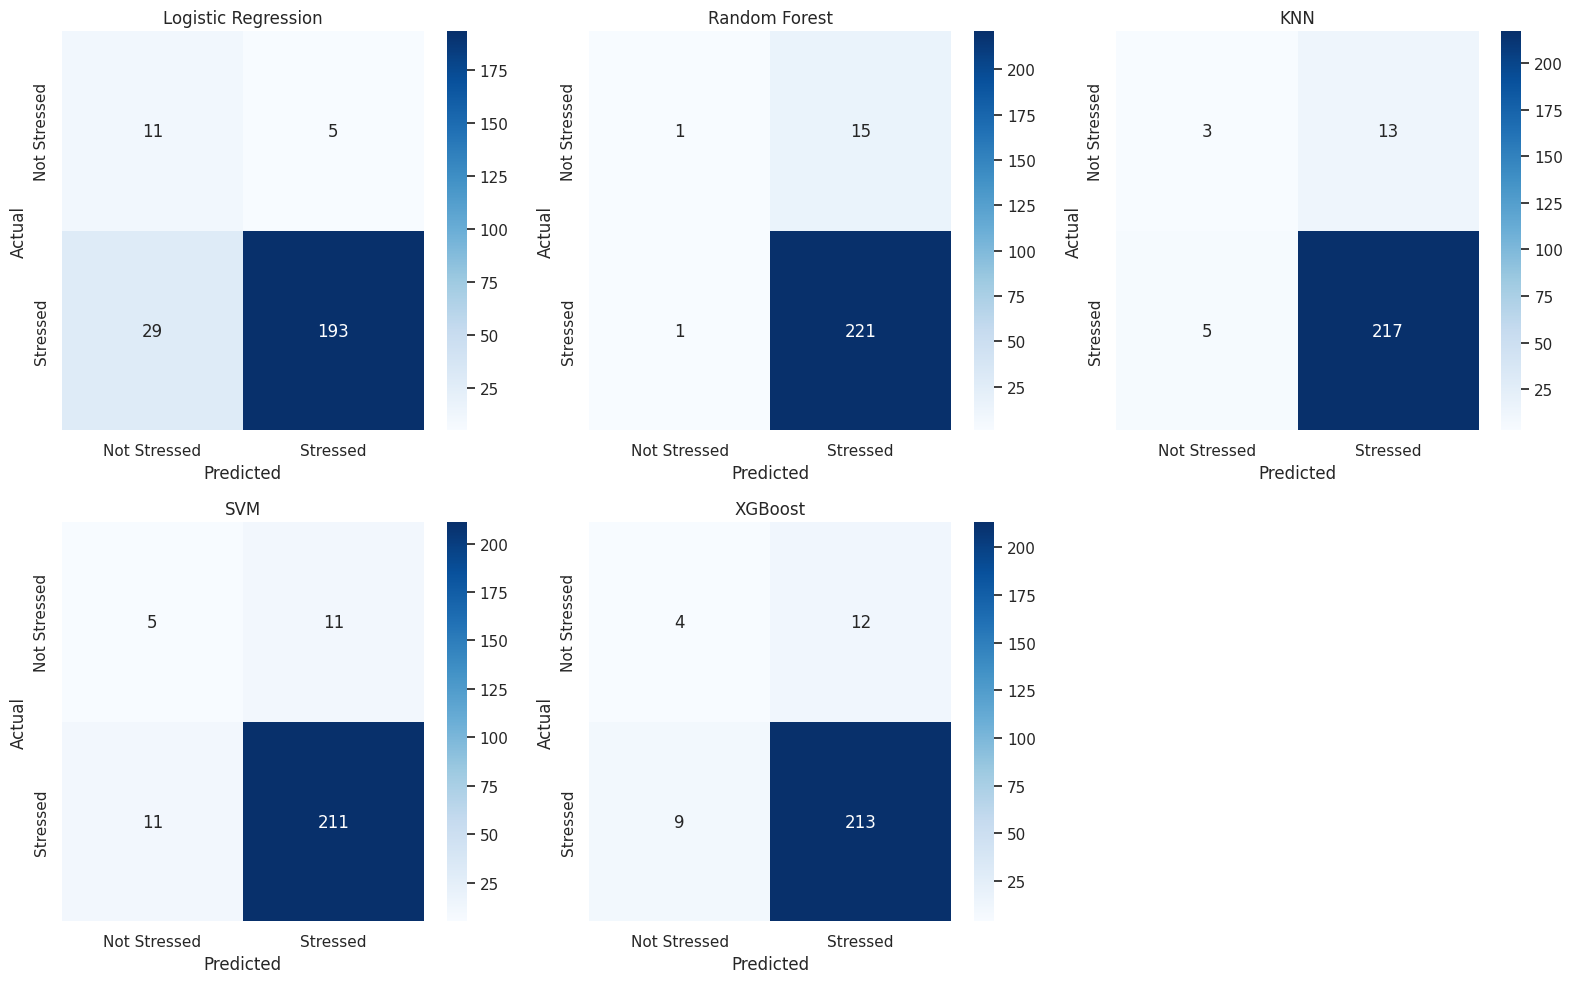

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Load data
X_train = pd.read_csv("X_train_sample.csv")
X_test = pd.read_csv("X_test_sample.csv")
y_train = pd.read_csv("y_train_binary.csv").squeeze()
y_test = pd.read_csv("y_test_binary.csv").squeeze()

# Scale inputs for models that require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models (same order as ROC comparison)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42)  # Removed use_label_encoder
}

# Set up 2x3 plot grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Use scaled data for relevant models
    X_tr = X_train_scaled if name in ["Logistic Regression", "KNN", "SVM", "XGBoost"] else X_train
    X_te = X_test_scaled if name in ["Logistic Regression", "KNN", "SVM", "XGBoost"] else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Stressed", "Stressed"],
                yticklabels=["Not Stressed", "Stressed"], ax=axes[i])
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove unused subplot (bottom right corner)
fig.delaxes(axes[-1])
fig.tight_layout()
fig.savefig("Github Uploads/confusion_matrices_all_models.png")
plt.show()

### Interpretation of Confusion Matrices

The confusion matrices for the different models reflect the nature of our classification problem, which involves an imbalanced dataset with more "Stressed" cases than "Not Stressed."  

- **Class Imbalance Effect:** Most predictions fall into the "Stressed" category, consistent with the higher number of stressed samples in both the training and test sets. This imbalance naturally biases the models toward predicting the majority class more often.

- **Model Performance Overview:**  
  - **Random Forest** shows the best balance, with relatively few false positives and false negatives, aligning with its strong accuracy and ROC-AUC scores.  
  - **Logistic Regression** and **SVM** also perform well but produce a slightly higher number of misclassifications.  
  - **K-Nearest Neighbors (KNN)** and **XGBoost** have more false positives, indicating some tendency to incorrectly label "Not Stressed" students as stressed.

- **Practical Implication:** The models are generally good at identifying stressed students but occasionally misclassify some non-stressed students, which may be acceptable depending on the application context (e.g., prioritizing catching stressed students for intervention).




## Testing Models on New Dataset

I have a new dataset collected by the same institution but in a different year. My goal is to:

- Clean and preprocess this new data similarly to the original dataset.
- Apply one of the models trained on the previous dataset to this new data to test their generalization performance.


## Initial Data Cleaning and Encoding for New Dataset

In this step, I clean the new dataset by handling missing values and applying the same categorical mappings as the original dataset. The target variable transformation into binary labels will be done later.


In [116]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("Student Insomnia and Educational Outcomes Dataset_version-2.csv")

# 2. Drop timestamp and strip question numbers
df.drop(columns=["Timestamp"], inplace=True)
df.columns = [col.split(" ", 1)[1].strip() for col in df.columns]

# 3. Define all mappings
year_map = {"First year": 1, "Second year": 2, "Third year": 3, "Graduate student": 4}
gender_map = {"Male": 0, "Female": 1}

fall_asleep_map = {
    "Never": 1, "Rarely (1-2 times a week)": 2, "Sometimes (3-4 times a week)": 3,
    "Often (5-6 times a week)": 4, "Every night": 5
}

sleep_hours_map = {"Less than 4 hours":1, "4-5 hours": 2, "6-7 hours": 3, "7-8 hours": 4, "More than 8 hours": 5}

wake_up_map = fall_asleep_map.copy()  # same scale as fall_asleep

sleep_quality_map = {
    "Very poor": 1, "Poor": 2, "Average": 3, "Good": 4, "Very good": 5
}

concentration_map = {
    "Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5
}

fatigue_map = concentration_map.copy()  # same as concentration

miss_class_map = {
    "Never": 1, "Rarely (1-2 times a month)": 2, "Sometimes (1-2 times a week)": 3,
    "Often (3-4 times a week)": 4, "Always": 5
}

impact_map = {"No impact": 1, "Minor impact": 2, "Moderate impact": 3, "Major impact": 4, "Severe impact": 5}

device_use_map = {
    "Never": 1, "Rarely (1-2 times a week)": 2, "Sometimes (3-4 times a week)": 3,
    "Often (5-6 times a week)": 4, "Every night": 5
}

caffeine_map = {
    "Never": 1, "Rarely (1-2 times a week)": 2, "Sometimes (3-4 times a week)": 3,
    "Often (5-6 times a week)": 4, "Every day": 5
}

exercise_map = caffeine_map.copy()  # same structure

stress_map = {
    "No stress": 1, "Low stress": 2, "High stress": 3, "Extremely high stress": 4
}

academic_perf_map = {
    "Poor": 1, "Below Average": 2, "Average": 3, "Good": 4, "Excellent": 5
}

# 4. Apply mappings
df["What is your year of study?"] = df["What is your year of study?"].map(year_map)
df["What is your gender?"] = df["What is your gender?"].map(gender_map)
df["How often do you have difficulty falling asleep at night?"] = df["How often do you have difficulty falling asleep at night?"].map(fall_asleep_map)
df["On average, how many hours of sleep do you get on a typical day?"] = df["On average, how many hours of sleep do you get on a typical day?"].map(sleep_hours_map)
df["How often do you wake up during the night and have trouble falling back asleep?"] = df["How often do you wake up during the night and have trouble falling back asleep?"].map(wake_up_map)
df["How would you rate the overall quality of your sleep?"] = df["How would you rate the overall quality of your sleep?"].map(sleep_quality_map)
df["How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?"] = df["How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?"].map(concentration_map)
df["How often do you feel fatigued during the day, affecting your ability to study or attend classes?"] = df["How often do you feel fatigued during the day, affecting your ability to study or attend classes?"].map(fatigue_map)
df["How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?"] = df["How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?"].map(miss_class_map)
df["How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?"] = df["How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?"].map(impact_map)
df["How often do you use electronic devices (e.g., phone, computer) before going to sleep?"] = df["How often do you use electronic devices (e.g., phone, computer) before going to sleep?"].map(device_use_map)
df["How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?"] = df["How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?"].map(caffeine_map)
df["How often do you engage in physical activity or exercise?"] = df["How often do you engage in physical activity or exercise?"].map(exercise_map)
df["How would you describe your stress levels related to academic workload?"] = df["How would you describe your stress levels related to academic workload?"].map(stress_map)
df["How would you rate your overall academic performance (GPA or grades) in the past semester?"] = df["How would you rate your overall academic performance (GPA or grades) in the past semester?"].map(academic_perf_map)

# 5. Rename to short column names
rename_map = {
    "What is your year of study?":              "year",
    "What is your gender?":                     "gender",
    "How often do you have difficulty falling asleep at night?": "fall_asleep",
    "On average, how many hours of sleep do you get on a typical day?": "sleep_hours",
    "How often do you wake up during the night and have trouble falling back asleep?": "wake_back",
    "How would you rate the overall quality of your sleep?":     "sleep_quality",
    "How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?": "concentration",
    "How often do you feel fatigued during the day, affecting your ability to study or attend classes?":  "fatigue",
    "How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?": "miss_class",
    "How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?": "impact_assignments",
    "How often do you use electronic devices (e.g., phone, computer) before going to sleep?": "device_use",
    "How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?": "caffeine_use",
    "How often do you engage in physical activity or exercise?": "exercise",
    "How would you describe your stress levels related to academic workload?": "stress_level",
    "How would you rate your overall academic performance (GPA or grades) in the past semester?": "academic_performance"
}

df.rename(columns=rename_map, inplace=True)

# 6. Handle missing values by imputing numeric columns with mean
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 7. Save final cleaned dataset
df.to_csv("Clean_2.csv", index=False)
df.to_csv("Github Uploads/Clean_2.csv", index=False)

### Creating Binary Stress Label and Splitting Data

I transform the stress level into a binary target:

- 1 and 2 → Not Stressed (0)
- 3 and 4 → Stressed (1)

Then I perform a stratified train-test split to maintain class balance in both sets.


In [117]:
import os
import pandas as pd

# Ensure save folder exists
os.makedirs("Github Uploads", exist_ok=True)

# === Load full original dataset as training data ===
df_train = pd.read_csv("Clean.csv")

# Create binary target variable for train set
df_train["binary_stress"] = df_train["stress_level"].apply(lambda x: 0 if x in [1, 2] else 1)

# Separate features and target
X_train = df_train.drop(columns=["stress_level", "binary_stress"])
y_train = df_train["binary_stress"]

# Save full training data splits
X_train.to_csv("Github Uploads/X_train_full.csv", index=False)
y_train.to_csv("Github Uploads/y_train_full.csv", index=False)

print("Training data shape:", X_train.shape)
print("Train class distribution:")
print(y_train.value_counts())

# === Load full new dataset as testing data ===
df_test = pd.read_csv("Clean_2.csv")

# Create binary target variable for test set
df_test["binary_stress"] = df_test["stress_level"].apply(lambda x: 0 if x in [1, 2] else 1)

# Separate features and target
X_test = df_test.drop(columns=["stress_level", "binary_stress"])
y_test = df_test["binary_stress"]

print("\nTesting data shape:", X_test.shape)
print("Test class distribution:")
print(y_test.value_counts())

Training data shape: (791, 14)
Train class distribution:
binary_stress
1    739
0     52
Name: count, dtype: int64

Testing data shape: (996, 14)
Test class distribution:
binary_stress
1    922
0     74
Name: count, dtype: int64


## Testing Pretrained Models on New Dataset

After training I models on the original dataset, I evaluate their performance on a new dataset collected separately. This process assesses the generalization ability of the models in detecting stress levels on unseen data.



Logistic Regression Test Accuracy: 0.81
Logistic Regression Test ROC-AUC: 0.91


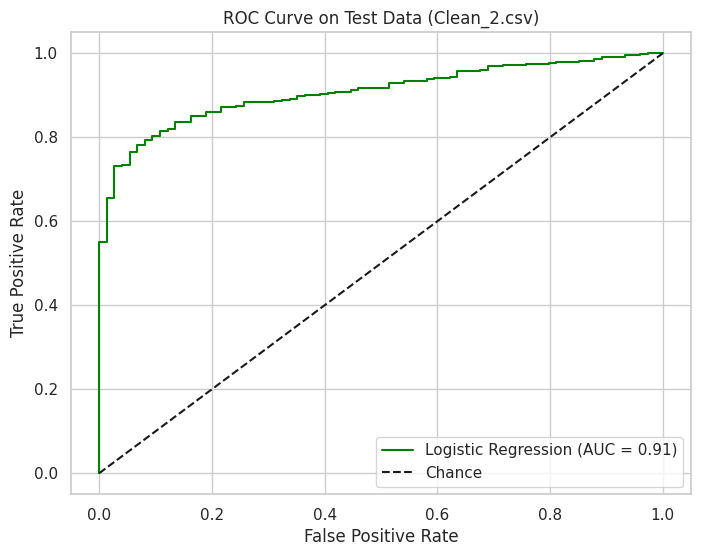

In [118]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

# Load preprocessed train/test sets
X_train = pd.read_csv("Github Uploads/X_train_full.csv")
y_train = pd.read_csv("Github Uploads/y_train_full.csv").squeeze()
X_test = X_test  # from above cell (or reload Clean_2.csv and preprocess similarly)
y_test = y_test

# Impute missing values
imputer = SimpleImputer(strategy="mean")
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train logistic regression
model = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Logistic Regression Test Accuracy: {acc:.2f}")
print(f"Logistic Regression Test ROC-AUC: {auc:.2f}")

# Save the plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})", color="green")
plt.plot([0,1], [0,1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Data (Clean_2.csv)")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("Github Uploads/logistic_regression_roc_curve.png")
plt.show()

#### Now, let's examine the confusion matrix to understand how well the model classifies stressed and not stressed students.


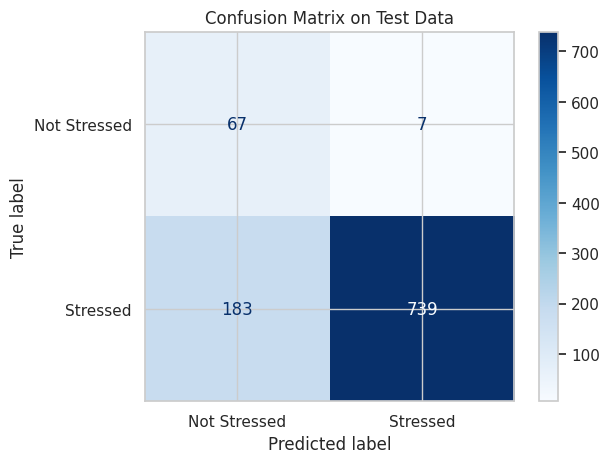

In [119]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# Assuming y_test and y_pred are already defined from your model's predictions

os.makedirs("Github Uploads", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Stressed", "Stressed"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Data")
plt.savefig("Github Uploads/logistic_regression_confusion_matrix.png")
plt.show()

### Model Generalization to New Dataset

The logistic regression model trained on the original dataset demonstrates strong performance when tested on the new dataset.  

- The ROC curve shows a high AUC score of 0.91, indicating excellent discriminative ability between stressed and not stressed students.
- The confusion matrix reveals that the model correctly classifies the majority of cases, with relatively few misclassifications.

These results confirm that the model generalizes well across datasets collected at different times, validating its robustness and practical applicability for stress level prediction in similar student populations.
